# Mean Reversion

The out-of-sample test results for the mean reversion strategy using OLS found that this method led to significantly worse performance on unseen data. In this notebook and the next, we consider the effect of combining this approach with the more robust PCA approach. As before, we isolate the idiosyncratic component of each crypto asset's returns, working under the assumption that they mean revert over short time horizons (4h). We then average the signals produced by both methods, with the aim of improving OLS performance during periods when its signal has weakened.

We backtest a cross-sectional mean reversion strategy using 4-hour crypto data from 2022 to 2024, across a universe of 70 crypto assets. We conduct a parameter sweep over the following: number of PCA components (1, 2, or 3), the market-proxy ticker for OLS (BTC or ETH), rolling window size (1–3 months), rho (the partial adjustment parameter that blends current weights with the previous period's weights to reduce turnover; 0.9 or 0.95), alpha (the EWM smoothing parameter applied to residuals before signal construction; 0.3, 0.5, or 0.7), and the rank threshold (which controls the fraction of assets assigned non-zero weights; 0.05 or 0.1). The optimal configuration is selected by maximising the net Sharpe ratio on the training period and evaluated out of sample.

The selected configuration uses 1 PCA component, BTC as the OLS market proxy, a rolling window of 1 month, rho of 0.95, a smoothing alpha of 0.5, and a rank threshold of 0.05. This yields a gross Sharpe ratio of 2.39, which reduces to 1.32 after turnover costs. The strategy delivers an average annualised return of 30% with annualised volatility of 13%. It is highly uncorrelated with the market (BTC), with a beta of 0.01, producing a statistically significant alpha of 30% (t-stat = 4.1).

In [1]:
cd -q ../../

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest_opt_combine, run_backtest
from src.backtest.helpers import sharpe
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

## Data

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [4]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)

In [5]:
px = px.loc[:"20250101"]

In [6]:
param_grid = {
    "mkt_ticker":      ["BTCUSDT", "ETHUSDT"],
    "n_comp":      [1, 2, 3],
    "window_size": [i*30*6 for i in range(1, 4)],
    "rho":         [0.9, 0.95],
    "alpha":       [0.3, 0.5, 0.7],
    "rank_thresh": [0.05, 0.1],
}

res = run_backtest_opt_combine(px, freq="4h", param_grid=param_grid)

2026-03-08 17:14:49,364 INFO: Resampled to 4h
Sweep: 100%|██████████| 18/18 [1:46:48<00:00, 356.05s/it]


In [7]:
res.head(10)

,n_comp,mkt_ticker,window_size,rho,alpha_ewm,rank_thresh,gross_sharpe,net_sharpe,avg_turnover,avg_ann,vol_ann,alpha,beta,alpha_tstat,hit_rate,avg_holding_days
0,3,BTCUSDT,360,0.95,0.3,0.05,2.198825,1.382284,0.032843,0.349814,0.159091,0.345997,0.010288,3.771513,0.571950,5.075703
1,2,BTCUSDT,360,0.95,0.3,0.05,2.150067,1.342123,0.032894,0.346503,0.161159,0.342420,0.011005,3.684875,0.570278,5.067869
2,3,ETHUSDT,360,0.95,0.3,0.05,2.156943,1.338587,0.032831,0.342758,0.158909,0.339241,0.009479,3.701797,0.570430,5.077618
3,3,BTCUSDT,360,0.95,0.5,0.05,2.348272,1.332010,0.032174,0.297204,0.126563,0.293678,0.009505,4.024771,0.579395,5.181048
4,1,BTCUSDT,180,0.95,0.5,0.05,2.389143,1.321823,0.032256,0.304058,0.127267,0.300047,0.010813,4.090202,0.568151,5.167904
5,2,BTCUSDT,180,0.95,0.5,0.05,2.383592,1.310649,0.032204,0.301368,0.126434,0.297392,0.010716,4.080684,0.569670,5.176132
6,3,BTCUSDT,180,0.95,0.5,0.05,2.395300,1.310019,0.032145,0.299029,0.124840,0.295023,0.010797,4.100052,0.567847,5.185738
7,2,ETHUSDT,360,0.95,0.3,0.05,2.114811,1.305842,0.032876,0.340601,0.161055,0.336800,0.010246,3.626429,0.571190,5.070672
8,1,ETHUSDT,180,0.95,0.5,0.05,2.381438,1.304632,0.032240,0.300671,0.126256,0.296739,0.010598,4.077397,0.569518,5.170417
9,3,ETHUSDT,360,0.95,0.5,0.05,2.322408,1.300359,0.032154,0.292390,0.125899,0.289234,0.008506,3.984177,0.579851,5.184360


## Results of Optimal Configuration

After running our parameter sweep, we find the optimal configuration to use 3 principal components, a rolling window of 360 bars (~60 days), rho of 0.95, alpha of 0.3, and a rank threshold of 0.05. However, although 3 components yields a marginally higher net Sharpe ratio of 1.38 compared to 1.32 for a single component, the difference is negligible and well within the range of estimation noise. We therefore select the single-component configuration on theoretical grounds: explained variance analysis shows that PC1 alone accounts for 50–70% of cross-sectional return variance, while PC2 and PC3 each contribute less than 5%. Including additional components beyond PC1 risks stripping out genuine idiosyncratic variation alongside the market factor, potentially weakening the mean reversion signal. The single-component model is also simpler, more interpretable, and less susceptible to overfitting the factor structure to the in-sample period. The marginal performance improvement from additional components does not justify the added complexity.

We therefore select the following configuration: 1 principal component for PCA, BTC as the OLS market proxy, a 30-day rolling window, rho of 0.95, alpha of 0.5, and a rank threshold of 0.05.

In [16]:
opt_setup = run_backtest(
    px,
    freq="4h", 
    rho=0.95, 
    rank_thresh=0.05, 
    alpha=0.5, 
    n_comp=1, 
    window_size=6*30, 
    mkt_ticker="BTCUSDT",
    method="combine",
    )

2026-03-08 19:10:49,476 INFO: Resampled to 4h


### Information Coefficient (IC) Analysis

The plot below shows the Information Coefficient (IC) at horizons of 1 through 24 bars, measured as the Spearman rank correlation between the residual signal at time t and forward returns at time t+h. A negative IC indicates that assets with high residuals (relative overperformers) tend to underperform at the next bar, and vice versa, which is consistent with mean reversion.

At h=1 (4 hours), the mean IC is -0.07, indicating a meaningful negative relationship between the residual ranking and subsequent returns. By h=2 (8 hours) the IC has decayed to -0.02, losing approximately 70% of its predictive strength in a single bar. At longer horizons the IC turns positive, suggesting mean reversion gives way to momentum, i.e. assets eventually drift back in their original direction after the initial reversal.

This rapid decay has two implications for our strategy design. First, it motivates rebalancing every bar (every 4 hours) rather than less frequently, since the signal is substantially weaker by h=2. Second, it explains why aggressive smoothing via the partial adjustment parameter (rho=0.95) and EWM residual smoothing (alpha=0.5) are necessary. Without these, the turnover required to act on the h=1 signal at every bar would be prohibitive at 20bps transaction costs.

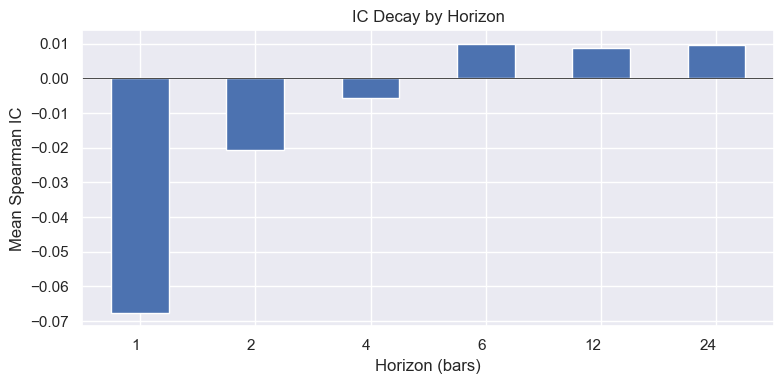

In [18]:
ic = opt_setup["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling net sharpe ratio

Below we plot the rolling 90-day net Sharpe ratio. The combined model produces results very similar to those of the individual models, which is expected given that the two signals are closely related. Notably, however, the combined model moderates performance during periods of extreme returns in either direction, dampening the highs when one model performs exceptionally well, but also cushioning the lows when one model performs poorly. This smoothing effect is a natural consequence of averaging the two signals.

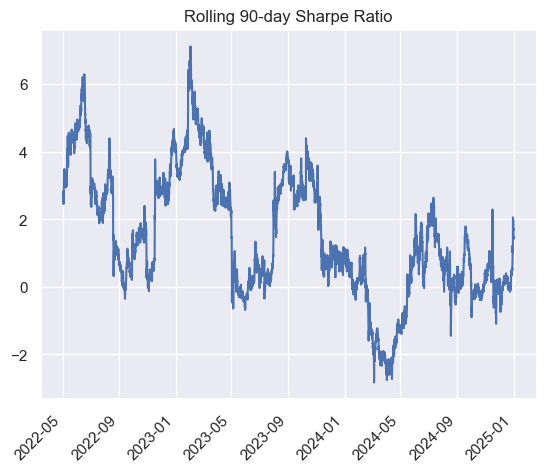

In [19]:
net_ret = opt_setup["net_ret"]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

We show the gross and net cumulative returns for our strategy, plotted against BTC buy-and-hold returns. Since the strategy is market-neutral, the comparison against BTC is intended to illustrate the absence of beta exposure rather than serve as a head-to-head performance benchmark. Notably, the combined model outperforms BTC from 2022 through to late 2024, after which BTC recovers strongly and outperforms both individual models, likely reflecting the broad crypto rally in that period rather than any deterioration in strategy quality.

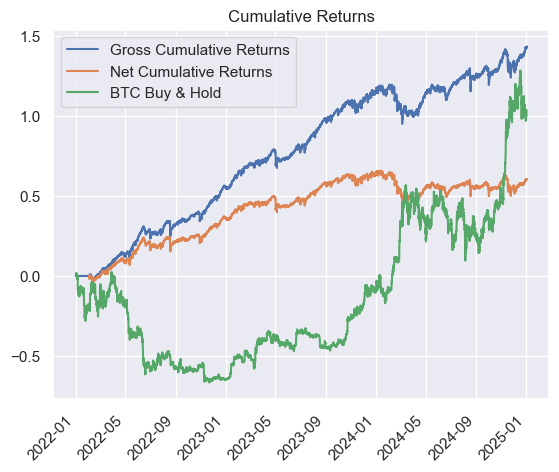

In [20]:
gross_cum = opt_setup["gross_cum"]
net_cum = opt_setup["net_cum"]

rets = rets.loc[:"20241231"]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Drawdown results are very similar to those seen for the individual models. The maximum drawdown is approximately -0.15, reached in March 2024, with the maximum drawdown duration of approximately 2,000 bars (~1 year), persisting through to the end of the sample.

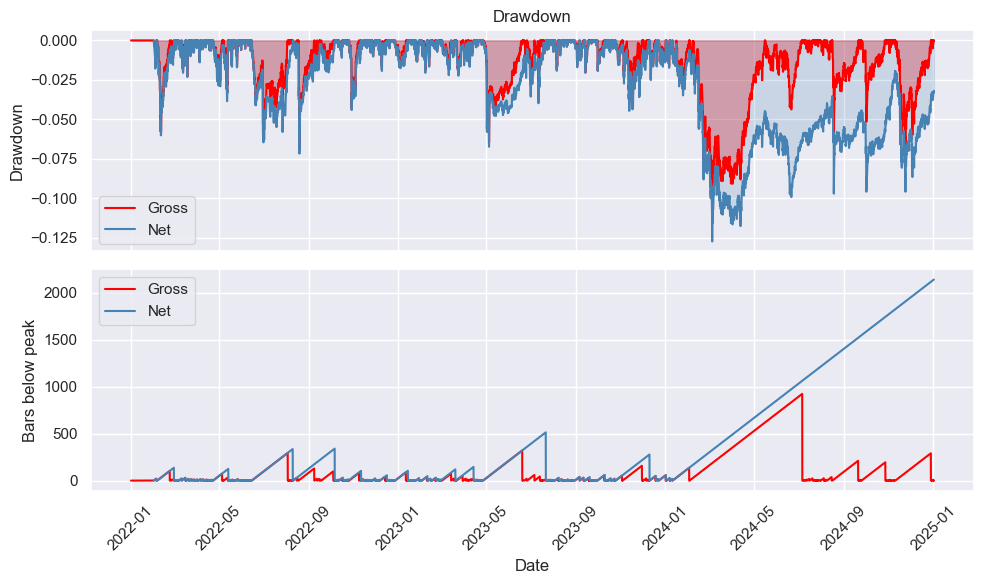

In [21]:
gross_ret = opt_setup["gross_ret"]
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

A key challenge in implementing this strategy is managing turnover sufficiently to remain profitable after transaction costs. We address this through two mechanisms: exponential weighted moving average smoothing of the residuals before signal construction, and partial adjustment of portfolio weights, which blends each period's target weights with the previous period's weights at rate rho. Together these reduce average turnover to 0.031 per bar. The plot below shows the resulting turnover over time.

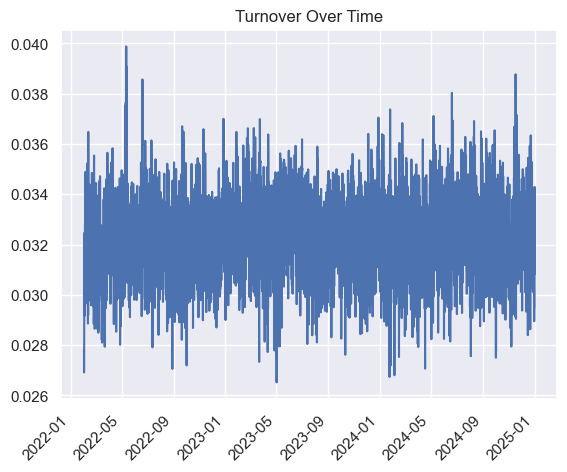

In [22]:
to = opt_setup["to"]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
plt.show()

Strategy performance degrades somewhat as transaction costs increase beyond our 20bps baseline. At 40bps the strategy remains profitable, though with a reduced net Sharpe ratio of 0.23. Notably, the combined model is less sensitive to turnover costs than either of the individual models, suggesting that signal averaging has a modest stabilising effect on portfolio turnover.

In [23]:
for bps in [15, 20, 30, 40]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

 15bps: net Sharpe = 1.60
 20bps: net Sharpe = 1.32
 30bps: net Sharpe = 0.77
 40bps: net Sharpe = 0.23
